# AIDS Clinical Trials Group Study 175 — ACTG175

## Chapters
0. Packages Importation and dataset uploading 
1. Introduction and Exploratory Data Analysis 
2. Survival Analysis: 

## 0. Packages Importation and dataset uploading

In [2]:

import pandas as pd  
import numpy as np           
import matplotlib.pyplot as plt   
import seaborn as sns       

from lifelines import KaplanMeierFitter, CoxPHFitter # Cox Model

from ucimlrepo import fetch_ucirepo 
df = fetch_ucirepo(id=890) 

X = df.data.features # Covariates
y = df.data.targets # Target

df = pd.concat([X, y], axis=1) 

## 1. Introduction and EDA
### 1.1 Dataset Description

The **AIDS Clinical Trials Group (ACTG) Study 175 Dataset** contains clinical and demographic information on patients diagnosed with HIV/AIDS who participated in the ACTG 175 clinical trial. The study, whose results were published in 1996, was designed to evaluate the effectiveness of different antiretroviral treatment strategies and to investigate factors associated with disease progression and survival.

The dataset includes a combination of demographic characteristics, clinical measurements, treatment assignments, and outcome variables collected during the study. The variables are described below:
| Variable  | Description                                                      | Type                   |
| --------- | ---------------------------------------------------------------- | ------------------------- |
| `time`    | days to event or censoring                                       | continuous covariate      |
| `cid`     | 1 = event (death/AIDS progression), 0 = censored                 | binary covariate          |
| `trt`     | treatment assignment (0=ZDV, 1=ZDV+ddI, 2=ZDV+Zal, 3=ddI)        | factor                    |
| `age`     | age at baseline (years)                                          | continuous covariate      |
| `wtkg`    | baseline weight (kg)                                             | continuous covariate      |
| `hemo`    | hemophilia status (0=no, 1=yes)                                  | binary covariate          |
| `homo`    | homosexual activity history (0=no, 1=yes)                        | binary covariate          |
| `drugs`   | history of intravenous drug use (0=no, 1=yes)                    | binary covariate          |
| `karnof`  | Karnofsky performance score (0–100)                              | continuous covariate      |
| `oprior`  | prior non-ZDV antiretroviral therapy (0=no, 1=yes)               | binary covariate          |
| `z30`     | ZDV use within 30 days before enrollment (0=no, 1=yes)           | binary covariate          |
| `zprior`  | prior ZDV use before enrollment (0=no, 1=yes)                    | binary covariate          |
| `preanti` | days of previous antiretroviral therapy                          | continuous covariate      |
| `race`    | race (0=white, 1=non-white)                                      | binary covariate          |
| `gender`  | sex (0=female, 1=male)                                           | binary covariate          |
| `str2`    | antiretroviral history stratum (0=naive, 1=experienced)          | binary covariate          |
| `symptom` | symptomatic status at baseline (0=no, 1=yes)                     | binary covariate          |
| `treat`   | grouped treatment indicator (0=ZDV only, 1=other therapies)      | binary covariate          |
| `offtrt`  | discontinued treatment before week 96 ± 5 (0=no, 1=yes)          | binary covariate          |
| `cd40`    | baseline CD4 cell count                                          | continuous covariate      |
| `cd420`   | CD4 cell count at week 20 ± 5                                    | continuous covariate      |
| `cd496`   | CD4 cell count at week 96 ± 5                                    | continuous covariate      |
| `cd80`    | baseline CD8 cell count                                          | continuous covariate      |
| `cd820`   | CD8 cell count at week 20 ± 5                                    | continuous covariate      |
| `pidnum`  | patient identifier                                               | ID, exclude from modeling |
| `strat`   | treatment stratification group                                   | factor                    |

The dimensions of the dataset can be easily obtained by counting the number of observations (rows) and variables (columns). As shown below, the dataset contains **2139** observations and **24** variables, all described in the previous section.

In [3]:

print(df.shape) # Dimension check

(2139, 24)


### 1.2 Explorative Data Analysis
After verifying that the dataset does not contain any missing values, we can proceed with the computation of descriptive statistics for each variable. These statistics provide an initial overview of the data distribution and help identify key characteristics, such as central tendency, variability, and the prevalence of different categories across the dataset.

In [4]:

missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values ✓")

Missing values:
No missing values ✓


In [5]:

df.describe().round(2)

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,cid
count,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,...,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00,2139.00
mean,879.10,1.52,35.25,75.13,0.08,0.66,0.13,95.45,0.02,0.55,...,0.59,1.98,0.17,0.75,0.36,350.50,371.31,986.63,935.37,0.24
std,292.27,1.13,8.71,13.26,0.28,0.47,0.34,5.90,0.15,0.50,...,0.49,0.90,0.38,0.43,0.48,118.57,144.63,480.20,444.98,0.43
min,14.00,0.00,12.00,31.00,0.00,0.00,0.00,70.00,0.00,0.00,...,0.00,1.00,0.00,0.00,0.00,0.00,49.00,40.00,124.00,0.00
25%,727.00,1.00,29.00,66.68,0.00,0.00,0.00,90.00,0.00,0.00,...,0.00,1.00,0.00,1.00,0.00,263.50,269.00,654.00,631.50,0.00
50%,997.00,2.00,34.00,74.39,0.00,1.00,0.00,100.00,0.00,1.00,...,1.00,2.00,0.00,1.00,0.00,340.00,353.00,893.00,865.00,0.00
75%,1091.00,3.00,40.00,82.56,0.00,1.00,0.00,100.00,0.00,1.00,...,1.00,3.00,0.00,1.00,1.00,423.00,460.00,1207.00,1146.50,0.00
max,1231.00,3.00,70.00,159.94,1.00,1.00,1.00,100.00,1.00,1.00,...,1.00,3.00,1.00,1.00,1.00,1199.00,1119.00,5011.00,6035.00,1.00


Focusing on the censoring status of the observations, the previous table shows that 24.4% of the data are censored (variable cid). The censoring mechanism is *right-censoring*, meaning that the event of interest has not occurred by the end of the observation period. Consequently, only an upper bound on the event time is available for these observations.

Firstly, we focus on the frequency of binary covariates:

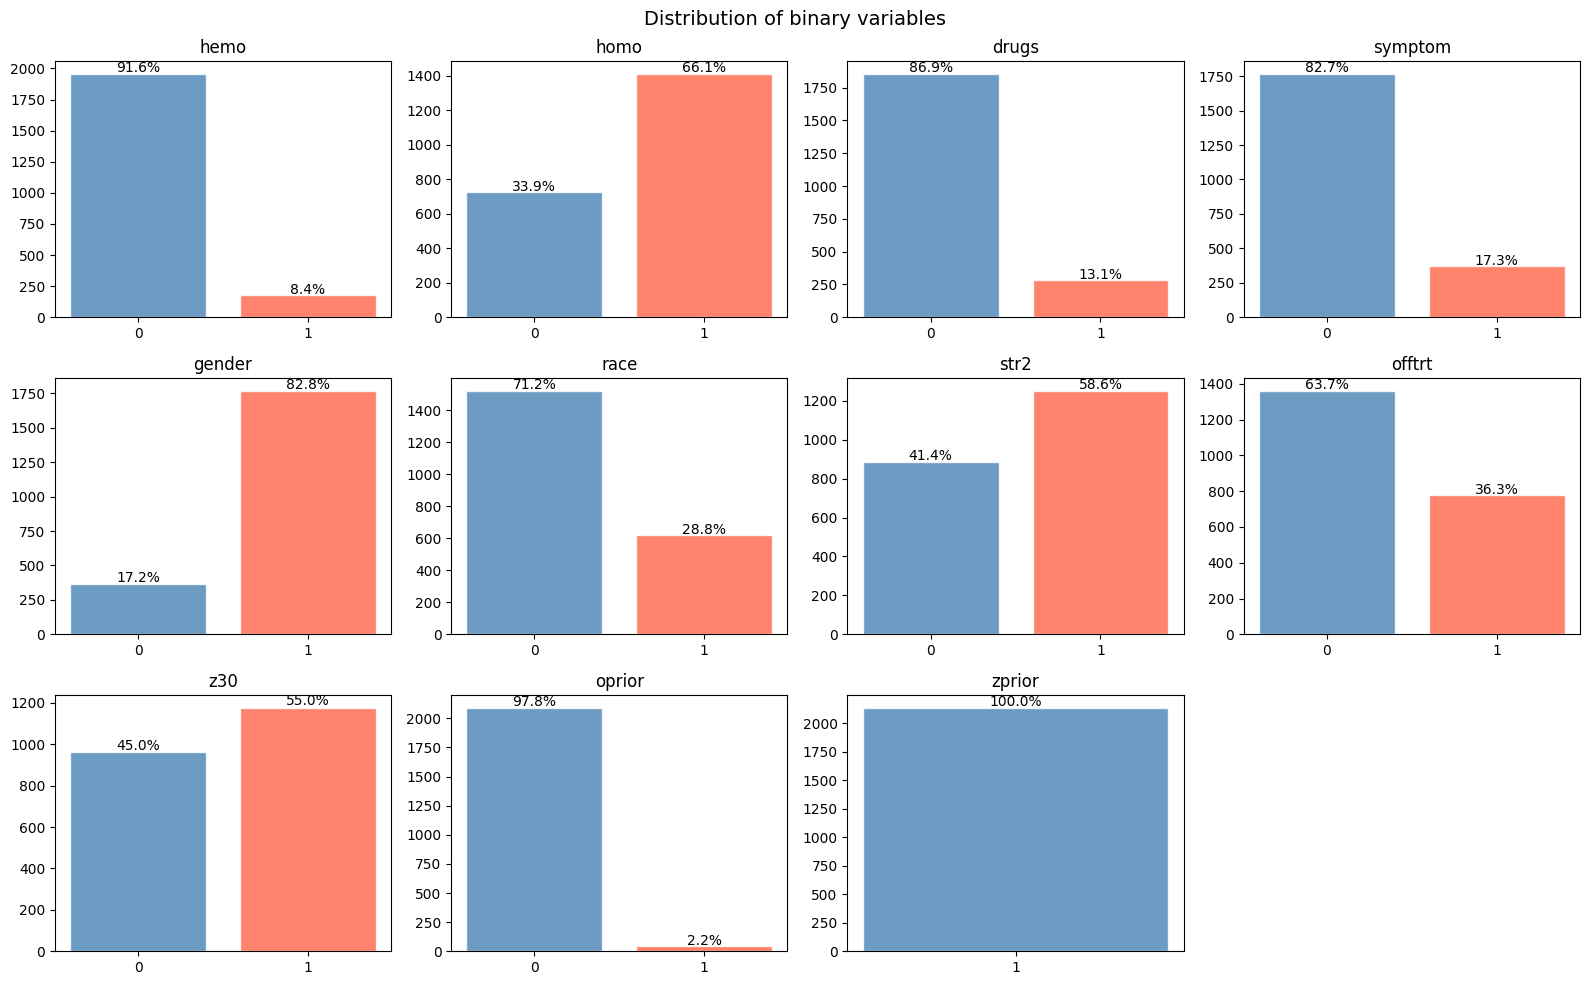

In [6]:

binary_vars = ['hemo', 'homo', 'drugs', 'symptom', 'gender', 'race', 'str2', 'offtrt', 'z30', 'oprior', 'zprior']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for ax, var in zip(axes, binary_vars):
    counts = df[var].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=['steelblue', 'tomato'], 
           edgecolor='white', alpha=0.8)
    ax.set_title(var)
    ax.set_xlabel('')
    # Aggiunge la percentuale sopra ogni barra
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, f'{v/len(df):.1%}', ha='center', fontsize=10)

# Nascondi assi vuoti
for ax in axes[len(binary_vars):]:
    ax.set_visible(False)

plt.suptitle('Distribution of binary variables', fontsize=14)
plt.tight_layout()
plt.show()

Among the binary variables, *zprior* is essentially constant across the sample and therefore carries no informative value for modelling. Similarly, *oprior* shows a highly skewed distribution, with 97.8% of patients falling into a single category, making it unlikely to contribute meaningfully to the analysis.

We then turn to the categorical variables:

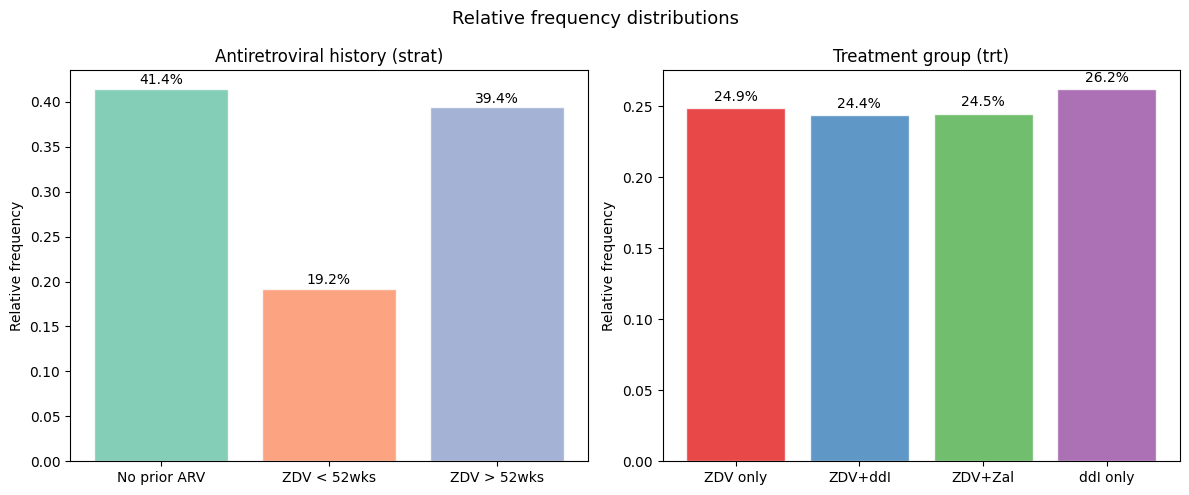

In [7]:

# strat
strat_labels = {1: 'No prior ARV', 2: 'ZDV < 52wks', 3: 'ZDV > 52wks'}
strat_counts = df['strat'].value_counts().sort_index()
axes[0].bar(strat_counts.index.map(strat_labels), strat_counts.values / len(df),
            color=['#66c2a5','#fc8d62','#8da0cb'], edgecolor='white', alpha=0.8)
axes[0].set_title('Antiretroviral history (strat)')
axes[0].set_ylabel('Relative frequency')
for i, v in enumerate(strat_counts.values / len(df)):
    axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

The dataset includes 2.139 HIV-positive patients enrolled in a clinical trial comparing four antiretroviral regimens: ZDV monotherapy (532), ZDV+ddI (522), ZDV+Zal (524), and ddI monotherapy (561). All three drugs (**Zidovudine, Didanosine, Zalcitabine**) belong to the NRTI class, the first generation of antiretroviral agents available in the early 1990s. The study, published in the New England Journal of Medicine in 1996, was designed to assess whether combination therapy offered a survival advantage over monotherapy, a question that ultimately shaped the modern standard of care for HIV treatment. The four treatment groups are well balanced in size, supporting the comparability of between-group analyses.

After assuring that, we can proceed to rappresent the histograms of the continuos variables:

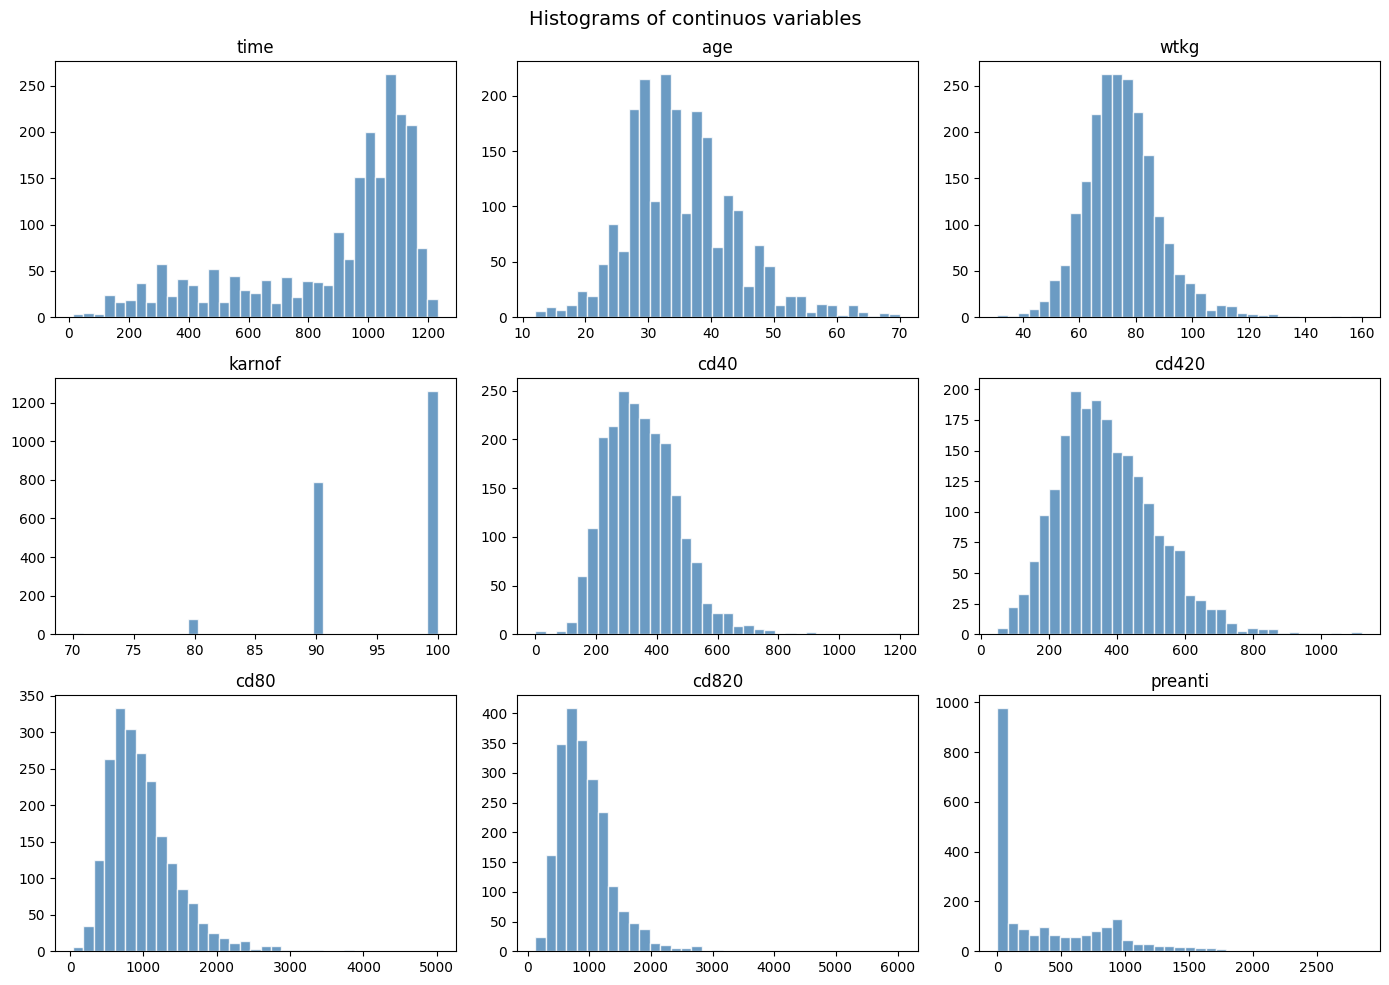

In [8]:

cont_vars = ['time', 'age', 'wtkg', 'karnof', 'cd40', 'cd420', 'cd80', 'cd820', 'preanti']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, var in zip(axes, cont_vars):
    ax.hist(df[var], bins=35, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(var)
    ax.set_xlabel('')

plt.suptitle('Histograms of continuos variables', fontsize=14)
plt.tight_layout()
plt.show()

We now focus on the relationship between treatment assignment and the outcome variable:

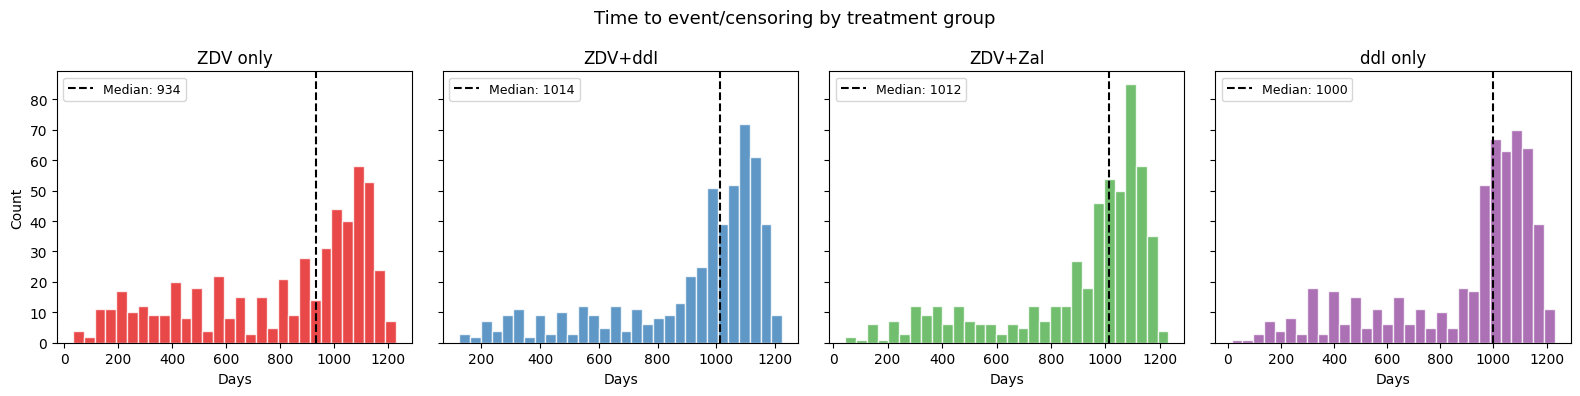

In [9]:

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

colors =  ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
trt_labels = {0: 'ZDV only', 1: 'ZDV+ddI', 2: 'ZDV+Zal', 3: 'ddI only'}

for ax, (trt_val, color) in zip(axes, zip([0,1,2,3], colors)):
    subset = df[df['trt'] == trt_val]['time']
    ax.hist(subset, bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(trt_labels[trt_val])
    ax.set_xlabel('Days')
    ax.axvline(subset.median(), color='black', linestyle='--', linewidth=1.5, label=f'Median: {subset.median():.0f}')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Count')
plt.suptitle('Time to event/censoring by treatment group', fontsize=13)
plt.tight_layout()
plt.show()

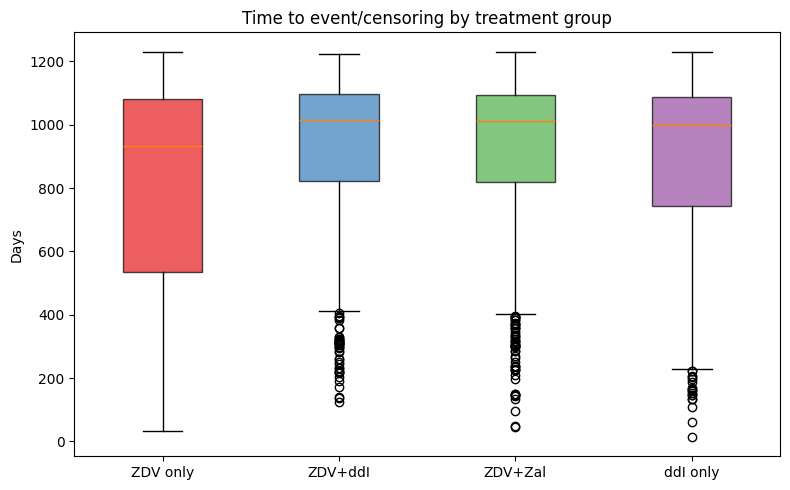

In [10]:

fig, ax = plt.subplots(figsize=(8, 5))

data_by_trt = [df[df['trt'] == t]['time'] for t in [0,1,2,3]]
bp = ax.boxplot(data_by_trt, tick_labels=trt_labels.values(), patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Days')
ax.set_title('Time to event/censoring by treatment group')
plt.tight_layout()
plt.show()

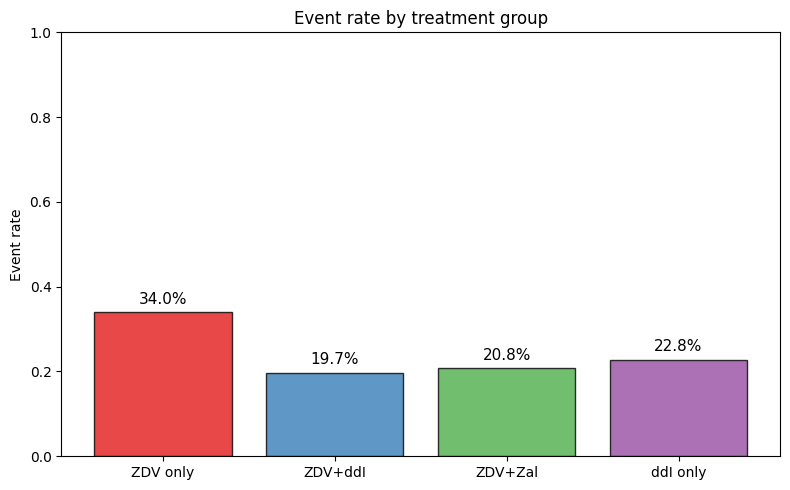

In [11]:

fig, ax = plt.subplots(figsize=(8, 5))

event_rate = df.groupby('trt')['cid'].mean()
ax.bar(trt_labels.values(), event_rate.values, color=colors, alpha=0.8, edgecolor='black')
ax.set_ylabel('Event rate')
ax.set_title('Event rate by treatment group')
ax.set_ylim(0, 1)
for i, v in enumerate(event_rate.values):
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

As shown in the plots, combined therapy regimens tend to be associated with longer survival times and lower event rates compared to monotherapy. This is historically consistent with the advent of **HAART** (Highly Active Antiretroviral Therapy) in 1996, which established multi-drug combinations as the standard of care for HIV/AIDS and remains so today.

We then examine the correlation matrix among continuous variables. Most covariates show weak to moderate correlations, with no major multicollinearity concerns. The most notable relationship is the strong positive correlation between **cd80** and **cd820**, representing CD8 cell counts at baseline and at 20 weeks respectively. CD8 cells, also known as *cytotoxic T lymphocytes*, are immune cells responsible for destroying virus-infected cells. Unlike **CD4** cells (*T helper lymphocytes*), which are the primary target of HIV and progressively depleted as the disease advances, CD8 cells are not directly attacked by the virus and therefore remain relatively stable over time. This biological stability explains why a patient with high CD8 at baseline is likely to maintain elevated levels 20 weeks later, regardless of treatment arm.

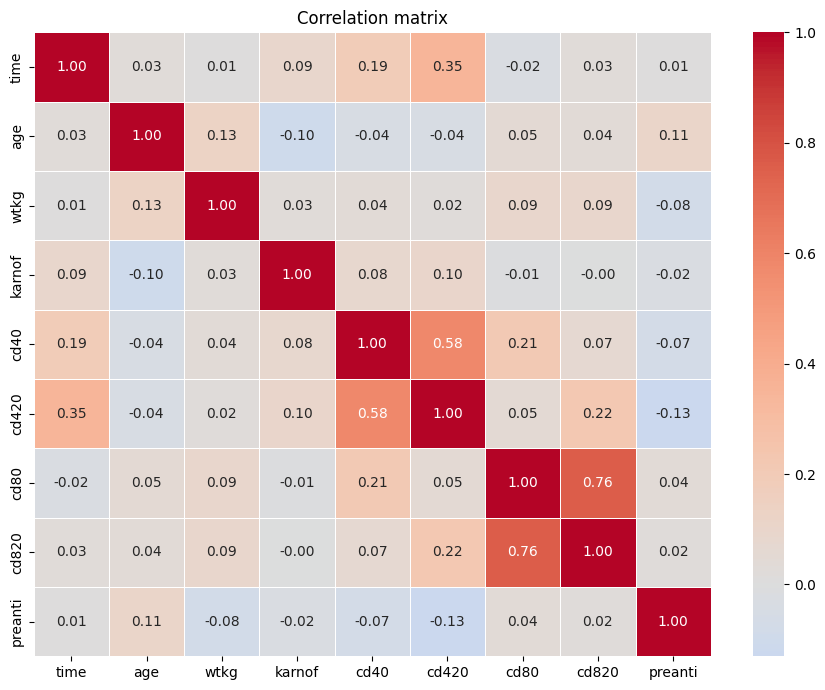

In [12]:

import seaborn as sns

cont_cols = ['time','age', 'wtkg', 'karnof', 'cd40', 'cd420', 'cd80', 'cd820', 'preanti']

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[cont_cols].corr().round(2), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()

### 1.3 Kaplan-Meier Estimator
Another way to assess the effect of treatment is to compare the estimated survival functions across the different treatment groups. To this end, we employ the **Kaplan–Meier estimator**, one of the most widely used non-parametric methods in survival analysis.

Let:
* $T > 0$ denote the random variable representing the survival time;
* $S(t)=P(T>t)$ denote the survival function;
* $t_{(1)} < t_{(2)} < \cdots < t_{(m)}$ denote the ordered event times;
* $d_i$ denote the number of observed events occurring at time $t_{(i)}$;
* $n_i$ denote the number of individuals at risk immediately before time $t_{(i)}$.

The Kaplan–Meier estimator is a non-parametric maximum likelihood estimator of the survival function in the presence of right-censored observations. It is defined as:
$$
\widehat{S}_{KM}(t) =\prod_{t_{(i)} \le t} \left(1-\frac{d_i}{n_i}\right)$$
This estimator can be interpreted as the product of the conditional probabilities of surviving beyond each observed event time. By estimating $\widehat{S}_{KM}(t)$ separately for each treatment group, it is possible to visually compare the corresponding survival experiences and assess whether substantial differences exist among the groups. It is important to note that the Kaplan–Meier estimator only accounts for group membership and does not adjust for additional covariates.


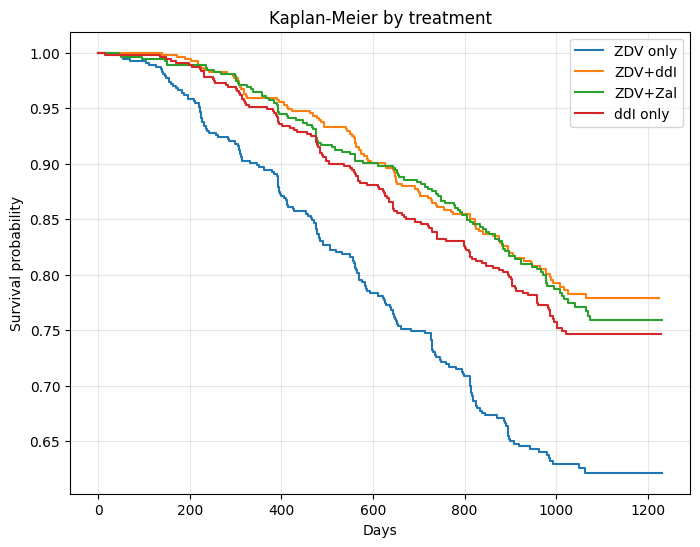

In [13]:

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for trt in sorted(df['trt'].unique()):
    mask = df['trt'] == trt

    kmf.fit(
        durations=df.loc[mask, 'time'],
        event_observed=df.loc[mask, 'cid'],
        label=trt_labels[trt]
    )

    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan-Meier by treatment")
plt.xlabel("Days")
plt.ylabel("Survival probability")
plt.grid(alpha=0.3)
plt.show()

Consistent with the findings of the previous exploratory analyses, the combination therapies appear to be associated with improved survival outcomes. In particular, the Kaplan–Meier curves corresponding to the mixed-treatment groups remain above those of the monotherapy groups for most of the follow-up period, indicating a higher estimated probability of survival over time. To formally assess whether these differences are statistically significant and to quantify the effect of treatment while accounting for other patient characteristics, we next consider a **Cox proportional hazards model**.


## 2. Cox Model
### 2.1 Theoretical Introduction
While the Kaplan–Meier estimator provides a useful graphical comparison of survival experiences across treatment groups, it does not account for the simultaneous effect of multiple covariates. To overcome this limitation, we employ the **Cox proportional hazards model**, one of the most widely used regression models in survival analysis.

Let:
* $T > 0$ denote the random variable representing the survival time;
* $X=(X_1,\ldots,X_p)$ denote the vector of covariates;
* $f(t)=\frac{d}{dt}F(t)=-\frac{d}{dt}S(t)$ denote the density function;
* $h(t)$ denotes the hazard function, defined as
$$h(t)=\frac{f(t)}{S(t)}$$
Intuitively, $h(t)$ represents the instantaneous rate at which the event occurs at time $t$, conditional on the individual having survived up to time $t$. More formally,
$$ h(t) = \lim_{\Delta t \to 0} \frac{P(t < T \leq t+\Delta t \mid T \geq t)}{\Delta t}$$
Therefore, the hazard function should not be interpreted as a probability, but rather as the instantaneous risk of experiencing the event at time $t$ given survival up to that time.

The Cox proportional hazards model assumes that the hazard function of an individual with covariate vector $X$ can be expressed as

$$h(t \mid X)= h_0(t) \exp\left(\beta X)\right),$$

where $\beta$ is the unknown vector of regression coefficients to be estimated from the data.

The model is said to be **semi-parametric** because it specifies a parametric form for the effect of the covariates through the exponential term, while leaving the baseline hazard function $h_0(t)$ unspecified.

A key assumption of the model is the **proportional hazards assumption**, which states that the hazard ratio between any two individuals remains constant over time. Indeed, for two covariate vectors $X_a$ and $X_b$, the ratio of their hazard functions is:
$$ \frac{h(t \mid X_a)} {h(t \mid X_b)}=\exp\left[(X_a-X_b)^T \beta \right],$$
which does not depend on time $t$.

The coefficients of the model are commonly interpreted through the **hazard ratio**
$$ HR_j = e^{\beta_j},$$
which measures the multiplicative change in the hazard associated with a one-unit increase in the covariate $X_j$, holding all other covariates constant. Values of $HR_j$ greater than one indicate an increased risk of experiencing the event, whereas values smaller than one indicate a reduced risk.

### 2.2 Fitting
In the context of this study, the Cox model allows us to assess the effect of treatment while simultaneously controlling for other relevant patient characteristics, such as age, body weight, Karnofsky score, and baseline CD4 counts. Therefore, it provides a more comprehensive evaluation of the factors influencing survival than the Kaplan–Meier analysis alone.


In [14]:

from lifelines import CoxPHFitter 

cox_vars = [col for col in df.columns if col not in ['pidnum', 'cd420', 'cd820', 'zprior', 'treat']] 

df_cox = df[cox_vars].copy()

trt_dummies = pd.get_dummies(df['trt'], prefix='trt', drop_first=False).astype(int) # Creating dummies variables for trt
trt_dummies = trt_dummies.drop(columns=['trt_0'])  # trt_0 = ZDV_only = base category
trt_dummies.columns = ['ZDV+ddI', 'ZDV+Zal', 'ddI_only']

df_cox = pd.concat([df_cox.drop(columns=['trt']), trt_dummies], axis=1)

cph = CoxPHFitter()
cph.fit(
    df_cox,
    duration_col='time',
    event_col='cid'
)
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 2139 total observations, 1618 right-censored observations>
             duration col = 'time'
                event col = 'cid'
      baseline estimation = breslow
   number of observations = 2139
number of events observed = 521
   partial log-likelihood = -3722.50
         time fit was run = 2026-06-18 16:38:25 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.01      1.01      0.01           -0.00            0.02                1.00                1.02
wtkg       0.00      1.00      0.00           -0.01            0.01                0.99                1.01
hemo      -0.04      0.96      0.22           -0.46            0.38                0.63                1.47
homo      -0.03      0.97      0.16           -0.34            0.28                0.71                1.32
drugs     -0.41      0.66      0.15           -0.71           -0.11                0.49                0.89
karnof    -0.02      0.98      0.01           -0.03           -0.01                0.97                0.99
oprior     0.06      1.06      0.28           -0.49            0.61                0.62                1.83
z30        0.24      1.27      0.23           -0.21            0.69                0.81                1.99
preanti    0.00      1.00      0.00            0.00            0.00                1.00                1.00
race      -0.06      0.94      0.11           -0.28            0.16                0.76                1.17
gender     0.07      1.07      0.18           -0.29            0.43                0.75                1.54
str2       0.17      1.19      0.31           -0.43            0.77                0.65                2.16
strat     -0.16      0.86      0.16           -0.47            0.15                0.63                1.17
symptom    0.39      1.47      0.10            0.18            0.59                1.20                1.81
offtrt     0.63      1.88      0.09            0.45            0.82                1.57                2.26
cd40      -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
cd80       0.00      1.00      0.00            0.00            0.00                1.00                1.00
ZDV+ddI   -0.76      0.47      0.12           -1.00           -0.51                0.37                0.60
ZDV+Zal   -0.66      0.51      0.12           -0.90           -0.42                0.41                0.65
ddI_only  -0.54      0.58      0.12           -0.77           -0.31                0.46                0.74

           cmp to     z      p  -log2(p)
covariate                               
age          0.00  1.61   0.11      3.22
wtkg         0.00  0.48   0.63      0.66
hemo         0.00 -0.18   0.85      0.23
homo         0.00 -0.19   0.85      0.24
drugs        0.00 -2.68   0.01      7.10
karnof       0.00 -2.79   0.01      7.59
oprior       0.00  0.22   0.83      0.27
z30          0.00  1.04   0.30      1.74
preanti      0.00  2.56   0.01      6.57
race         0.00 -0.52   0.60      0.73
gender       0.00  0.37   0.71      0.49
str2         0.00  0.56   0.57      0.80
strat        0.00 -0.99   0.32      1.63
symptom      0.00  3.71 <0.005     12.23
offtrt       0.00  6.85 <0.005     36.93
cd40         0.00 -8.39 <0.005     54.19
cd80         0.00  5.27 <0.005     22.83
ZDV+ddI      0.00 -6.08 <0.005     29.60
ZDV+Zal      0.00 -5.44 <0.005     24.17
ddI_only     0.00 -4.59 <0.005     17.78
---
Concordance = 0.71
Partial AIC = 7485.00
log-likelihood ratio test = 286.40 on 20 df
-log2(p) of ll-ratio test = 160.52


The model shows good discriminative ability, with a **concordance index of 0.71**, meaning the model correctly ranks 71% of patient pairs by their relative risk, which is considered good in a clinical setting (0.5 = random, 1.0 = perfect). The likelihood ratio test is highly significant, confirming that the model as a whole explains a substantial portion of the variation in survival.

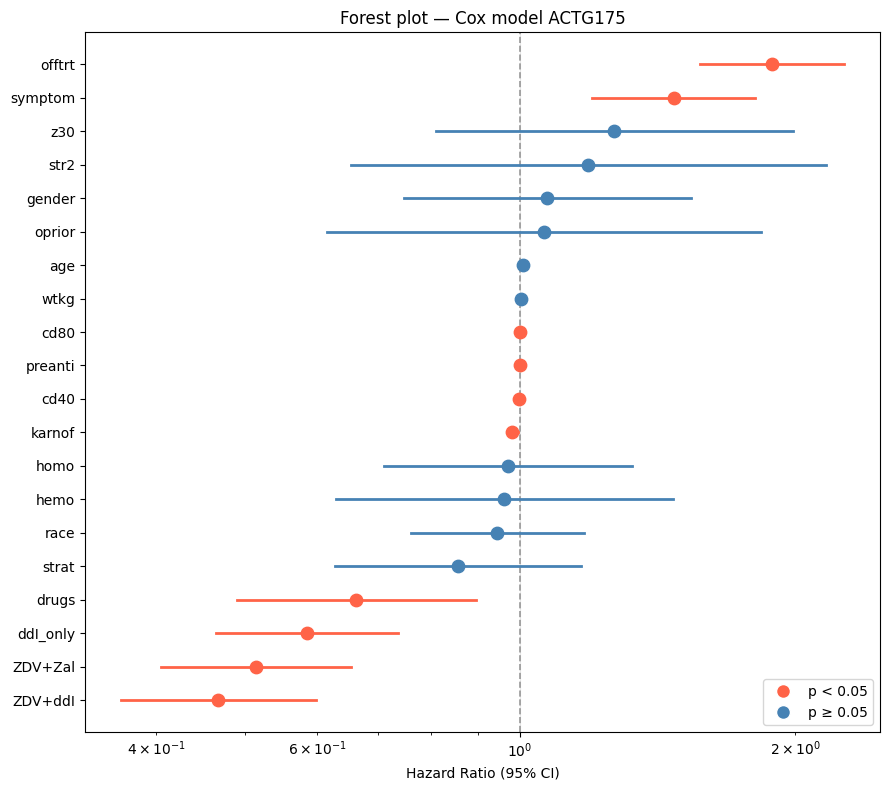

In [15]:

fig, ax = plt.subplots(figsize=(9, 8))

results = cph.summary.copy()
results['HR']       = np.exp(results['coef'])
results['HR_lower'] = np.exp(results['coef lower 95%'])
results['HR_upper'] = np.exp(results['coef upper 95%'])


res_plot = results.sort_values('HR', ascending=True)
y_pos = range(len(res_plot))

ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.2, alpha=0.8)

for i, (idx, row) in enumerate(res_plot.iterrows()):
    color = 'tomato' if row['p'] < 0.05 else 'steelblue'
    ax.plot([row['HR_lower'], row['HR_upper']], [i, i], color=color, linewidth=2)
    ax.scatter(row['HR'], i, color=color, zorder=5, s=80)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(res_plot.index.tolist())
ax.set_xlabel('Hazard Ratio (95% CI)')
ax.set_title('Forest plot — Cox model ACTG175')
ax.set_xscale('log')
ax.grid(axis='x', alpha=0.3)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato', markersize=10, label='p < 0.05'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=10, label='p ≥ 0.05'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

All three alternative regimens are associated with significantly lower hazard compared to ZDV alone. The strongest protective effect is seen with **ZDV+ddI**, followed by **ZDV+Zal**  and **ddI monotherapy**. This confirms the EDA findings: combination therapy, and even ddI monotherapy, outperforms the ZDV-only standard of the time.

Higher **CD4 count at baseline** is strongly protective, as expected since CD4 is the primary marker of immune function in HIV. Conversely, higher **CD8 count** is associated with increased hazard, which may reflect immune activation in response to disease progression. Patients with **symptoms at baseline** show higher risk, consistent with more advanced disease. A higher **Karnofsky score** is protective , reflecting better overall health status. Notably, **IV drug use** is associated with lower hazard, which may seem counterintuitive but could reflect closer clinical monitoring in this subgroup.

**Age, weight, hemophilia, homosexual activity, race, gender, antiretroviral history**, and prior opportunistic infections (**oprior**) do not reach statistical significance, suggesting that, conditional on the other variables, they do not independently predict survival in this cohort.

*offtrt* (whether the patient discontinued the assigned treatment) shows the strongest positive association with hazard. This is expected by design: patients who discontinue treatment are likely doing so because of disease progression or side effects.


### 2.3 Variables Selection
A backward stepwise procedure removed 10 variables sequentially, retaining only those with $p < 0.05$. The final model includes 10 predictors and maintains the same concordance index (0.71) as the full model, while the AIC improves from 7485 to 7472, confirming that the removed variables were genuinely non-informative.

In [16]:

import warnings
warnings.filterwarnings('ignore')

selected_vars = [col for col in df_cox.columns if col not in ['time', 'cid']]

while True:
    cph_step = CoxPHFitter()
    cph_step.fit(df_cox[['time', 'cid'] + selected_vars], 
                 duration_col='time', event_col='cid', show_progress=False)
    
    p_values = cph_step.summary['p']
    max_p = p_values.max()
    
    if max_p < 0.05:
        break
    
    worst_var = p_values.idxmax()
    selected_vars.remove(worst_var)

print(f"\n Selected variables ({len(selected_vars)}):", selected_vars)

cph_final = CoxPHFitter()
cph_final.fit(df_cox[['time', 'cid'] + selected_vars],
              duration_col='time', event_col='cid', show_progress=False)

cph_final.print_summary()


 Selected variables (10): ['drugs', 'karnof', 'preanti', 'symptom', 'offtrt', 'cd40', 'cd80', 'ZDV+ddI', 'ZDV+Zal', 'ddI_only']


<lifelines.CoxPHFitter: fitted with 2139 total observations, 1618 right-censored observations>
             duration col = 'time'
                event col = 'cid'
      baseline estimation = breslow
   number of observations = 2139
number of events observed = 521
   partial log-likelihood = -3726.38
         time fit was run = 2026-06-18 16:38:27 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
drugs     -0.39      0.68      0.15           -0.68           -0.10                0.51                0.90
karnof    -0.02      0.98      0.01           -0.03           -0.01                0.97                0.99
preanti    0.00      1.00      0.00            0.00            0.00                1.00                1.00
symptom    0.39      1.47      0.10            0.19            0.59                1.21                1.80
offtrt     0.62      1.87      0.09            0.44            0.81                1.56                2.24
cd40      -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
cd80       0.00      1.00      0.00            0.00            0.00                1.00                1.00
ZDV+ddI   -0.76      0.47      0.12           -1.00           -0.52                0.37                0.60
ZDV+Zal   -0.66      0.52      0.12           -0.90           -0.42                0.41                0.65
ddI_only  -0.55      0.58      0.12           -0.78           -0.32                0.46                0.72

           cmp to     z      p  -log2(p)
covariate                               
drugs        0.00 -2.66   0.01      6.99
karnof       0.00 -3.10 <0.005      9.01
preanti      0.00  5.06 <0.005     21.16
symptom      0.00  3.78 <0.005     12.64
offtrt       0.00  6.80 <0.005     36.47
cd40         0.00 -8.60 <0.005     56.82
cd80         0.00  5.47 <0.005     24.39
ZDV+ddI      0.00 -6.11 <0.005     29.94
ZDV+Zal      0.00 -5.45 <0.005     24.25
ddI_only     0.00 -4.73 <0.005     18.76
---
Concordance = 0.71
Partial AIC = 7472.77
log-likelihood ratio test = 278.64 on 10 df
-log2(p) of ll-ratio test = 177.05